# Likelihood scan

This tutorial shows how to produce a likelihood scan for a certain source hypothesis.

For analysis setup details check the [Fitting a steady point-source with the public 14-year IceCube track data](fitting_a_source.ipynb) tutorial.

In [1]:
import numpy as np
import scipy.stats
from matplotlib import pyplot as plt

import skyllh
from skyllh.analyses.i3.publicdata_ps.time_integrated_ps import create_analysis
from skyllh.core.config import Config
from skyllh.core.source_model import PointLikeSource

cfg = Config()

datasets = skyllh.create_datasets('IceTracks-DR2', cfg=cfg)


src_ra = 40.67  # degrees
src_dec = -0.01  # degrees

source = PointLikeSource(ra=np.radians(src_ra), dec=np.radians(src_dec))

ana = create_analysis(cfg=cfg, datasets=datasets, source=source)

100%|██████████| 136/136 [00:00<00:00, 10281.45it/s]


Unblind the analysis for later `TS` comparison to `llhratio_value`:

In [2]:
from skyllh.core.random import RandomStateService

rss = RandomStateService(seed=1)

ts, fitparam_values, status = ana.unblind(rss)

print(f'TS = {ts:.3f}')
print(f'ns = {fitparam_values["ns"]:.2f}')
print(f'gamma = {fitparam_values["gamma"]:.2f}')

TS = 29.154
ns = 80.09
gamma = 3.21


## Evaluating the log-likelihood ratio function

We need to evaluate the log-likelihood ratio function to generate a likelihood contour plot. The `Analysis` instance has the property `llhratio` which holds the instance of the log-likelihood ratio function. This instance has the method `evaluate`. The method takes an array of the fit parameter values as argument at which the LLH ratio function will be evaluated. It returns the value of the LLH ratio function at the given point and its gradients w.r.t. the fit parameters.

In our case this is the number of signal events, $n_{\mathrm{s}}$ and the spectral index $\gamma$. If we evaluate the LLH ratio function at the maximum, the gradients should be close to zero.

In [3]:
help(ana.llhratio.evaluate)

Help on method evaluate in module skyllh.core.llhratio:

evaluate(fitparam_values, src_params_recarray=None, tl=None) method of skyllh.core.llhratio.MultiDatasetTCLLHRatio instance
    Evaluates the composite log-likelihood-ratio function and returns its
    value and global fit parameter gradients.

    Parameters
    ----------
    fitparam_values : instance of numpy ndarray
        The (N_fitparams,)-shaped numpy 1D ndarray holding the current
        values of the global fit parameters.
    src_params_recarray : instance of numpy record ndarray | None
        The numpy record ndarray of length N_sources holding the parameter
        names and values of all sources.
        See the documentation of the
        :meth:`skyllh.core.parameters.ParameterModelMapper.create_src_params_recarray`
        method for more information about this array.
        It case it is ``None``, it will be created automatically from the
        ``fitparam_values`` argument using the
        :class:`~skyllh

In [4]:
(llhratio_value, (grad_ns, grad_gamma)) = ana.llhratio.evaluate([80.09, 3.21])
print(f'llhratio_value = {llhratio_value:.3f}')
print(f'grad_ns = {grad_ns:.3f}')
print(f'grad_gamma = {grad_gamma:.3f}')

llhratio_value = 14.577
grad_ns = 0.000
grad_gamma = -0.021


Using the `evaluate` method of the `LLHRatio` class we can scan the log-likelihood ratio space and create a contour plot showing the best fit and the 68%, 90%, and 95% quantile assuming Wilks' theorem.

Please be aware that this is an illustraative example. Whether the conditions that satisfy Wilks' theorem hold is left to the user as it will depend on the specific analysis being run and on the signal strength.

To produce a likelihood scan, we create a grid of flux normalization and spectral index values. Then we convert the flux normalization values into mean number of signal events, which is what we can evaluate the LH on. Finally, we evalutate the LLH ratio at each grid point $(n_{\mathrm{s}}, \gamma)$.

The log-likelihood ratio is then given by

$$\Delta\log\mathcal{L} = \log\mathcal{L}(\hat{n}_{\mathrm{s}}, \hat\gamma) - \log\mathcal{L}(n_{\mathrm{s}}, \gamma)$$

where $(\hat{n}_{\mathrm{s}}, \hat\gamma)$ are the maximum likelihood estimators.

Conveniently, the $\Delta\log\mathcal{L}$ can also be written as

$$\log\mathcal{L}(\hat{n}_{\mathrm{s}}, \hat\gamma) - \log\mathcal{L}(n_{\mathrm{s}}, \gamma) = \log\frac{\mathcal{L}(\hat{n}_{\mathrm{s}}, \hat\gamma)}{\mathcal{L}(n_{\mathrm{s}}=0)} - \log\frac{\mathcal{L}(n_{\mathrm{s}}, \gamma)}{\mathcal{L}(n_{\mathrm{s}}=0)} = \mathrm{TS}(\hat{n}_{\mathrm{s}}, \hat\gamma) - \mathrm{TS}(n_{\mathrm{s}}, \gamma)$$

So we can directly evaluate our test statistics at the values of interest:

In [5]:
(flux_min, flux_max, flux_step) = (-15, -12, 0.05)
(gamma_min, gamma_max, gamma_step) = (2.0, 4.0, 0.05)

flux_edges = np.logspace(flux_min, flux_max, int((flux_max - flux_min) / flux_step) + 1)
flux_vals = 0.5 * (flux_edges[1:] + flux_edges[:-1])

gamma_edges_flux = np.linspace(gamma_min, gamma_max, int((gamma_max - gamma_min) / gamma_step + 1))
gamma_vals_flux = 0.5 * (gamma_edges_flux[1:] + gamma_edges_flux[:-1])

flux_scaling_factor = ana.calculate_fluxmodel_scaling_factor(
    fitparam_values=[fitparam_values['ns'], fitparam_values['gamma']]
)

delta_ts_flux = np.empty((len(flux_vals), len(gamma_vals_flux)), dtype=np.double)
for flux_i, flux in enumerate(flux_vals):
    ns = flux / flux_scaling_factor
    for gamma_i, gamma in enumerate(gamma_vals_flux):
        delta_ts_flux[flux_i, gamma_i] = ana.calculate_test_statistic(
            ana.llhratio.evaluate([fitparam_values['ns'], fitparam_values['gamma']])[0],
            [fitparam_values['ns'], fitparam_values['gamma']],
        ) - ana.calculate_test_statistic(ana.llhratio.evaluate([ns, gamma])[0], [ns, gamma])

# Determine the best fit flux and gamma values from the scan.
index_max = np.argmin(delta_ts_flux)
flux_i_max = int(index_max / len(gamma_vals_flux))
gamma_i_max_flux = index_max % len(gamma_vals_flux)
flux_best = flux_vals[flux_i_max]
gamma_best_flux = gamma_vals_flux[gamma_i_max_flux]

The contours are computed assuming that the Wilks' theorem holds true. That is the TS distribution follows the $\chi^2$ distribution with 2 degrees of freedom, in this example.

In [6]:
chi2_68_quantile_flux = scipy.stats.chi2.ppf(0.68, df=2)
chi2_90_quantile_flux = scipy.stats.chi2.ppf(0.90, df=2)
chi2_95_quantile_flux = scipy.stats.chi2.ppf(0.95, df=2)

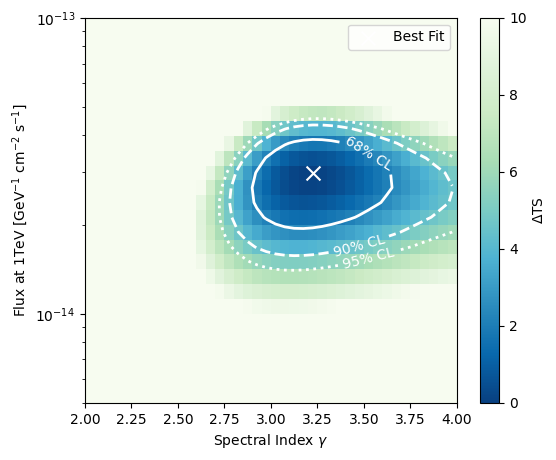

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
im = ax.pcolormesh(gamma_edges_flux, flux_edges, delta_ts_flux, vmin=0, vmax=10, cmap='GnBu_r')
cbar = plt.colorbar(im)
cbar.set_label(r'$\Delta$TS')

ax.scatter([gamma_best_flux], [flux_best], color='w', marker='x', s=100, label='Best Fit')
contour_68 = ax.contour(
    gamma_vals_flux, flux_vals, delta_ts_flux, levels=[chi2_68_quantile_flux], colors='w', linestyles='-', linewidths=2
)
contour_90 = ax.contour(
    gamma_vals_flux, flux_vals, delta_ts_flux, levels=[chi2_90_quantile_flux], colors='w', linestyles='--', linewidths=2
)
contour_95 = ax.contour(
    gamma_vals_flux, flux_vals, delta_ts_flux, levels=[chi2_95_quantile_flux], colors='w', linestyles=':', linewidths=2
)

ax.set_xlabel(r'Spectral Index $\gamma$')
ax.set_ylabel(r'Flux at 1TeV [GeV$^{-1}$ cm$^{-2}$ s$^{-1}$]')

ax.set_yscale('log')
ax.set_ylim(5e-15, 1e-13)

ax.clabel(contour_68, fmt={chi2_68_quantile_flux: '68% CL'}, fontsize=10, inline=True, inline_spacing=5, manual=False)
ax.clabel(contour_90, fmt={chi2_90_quantile_flux: '90% CL'}, fontsize=10, inline=True, inline_spacing=5, manual=False)
ax.clabel(contour_95, fmt={chi2_95_quantile_flux: '95% CL'}, fontsize=10, inline=True, inline_spacing=5, manual=False)

plt.legend(loc='upper right')
plt.show()